# Laboratorio 8: DuckDB

## Ejercicios 1 y 2. Ambiente y sistema de descarga

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

CC3084 Data Science, Semestre II 2026 | 2026-10-06

**Pregunta:** el ambiente Docker levanta los servicios del laboratorio y el sistema de descarga obtiene completos los viajes de taxis amarillos y verdes publicados para 2026?

**Repositorio base (1.1).** El enunciado pide trabajar sobre un fork del repositorio del docente, `menene/duckdb`. El equipo entrega en su repositorio de laboratorios, asi que el repositorio base se copio sin ningun cambio en `Lab8/` en un commit propio (`chore: repositorio base del Lab8 proporcionado por el docente`) y cada modificacion posterior va en commits separados. El historial cumple la funcion del fork: muestra que traia el repositorio base y que cambio el equipo.

**Ambiente (1.2).** Desde la carpeta `Lab8`:

```
docker compose up -d --build
```

levanta dos servicios: `lab` (JupyterLab con Python y DuckDB, en http://localhost:8888) y `metabase` (Metabase con el driver de DuckDB, en http://localhost:3000). Este cuaderno corre dentro del servicio `lab`:

```
docker compose exec lab jupyter nbconvert --to notebook --execute --inplace notebooks/01_Ambiente_y_Descarga.ipynb
```

**Datos.** Los Parquet de la TLC no se versionan. Este cuaderno los descarga con `scripts/download_data.py` hacia `data/raw/<tipo>/2026/`, y la tabla de zonas hacia `data/raw/zonas/`. Lo que ya esta en disco no se vuelve a bajar.

## Mapa del notebook

1. Imports y configuracion
2. Obtencion de datos: servicios, herramientas y el script de descarga (2.1 y 2.6)
3. Preparacion de datos: tablas de inventario y de verificacion
4. Variables: no aplica en este cuaderno
5. Metricas: completitud de la descarga
6. Graficas: registros por archivo mensual
7. Ejecucion: servicios (1.3), herramientas (1.4), descarga (2.2 y 2.3), no repeticion (2.4), verificacion contra el servidor (2.5) y registros por archivo (2.7)
8. Conclusiones (1.6 y 2.7)

## 1. Imports y configuracion

Las rutas salen de `scripts/consultas.py`, que las resuelve desde su propia ubicacion: el cuaderno corre igual desde `notebooks/`, desde la raiz del laboratorio o dentro del contenedor. Los dos colores de taxi se repiten en todos los cuadernos del laboratorio. Este cuaderno no usa aleatoriedad; `SEED` queda definido por convencion.

In [1]:
import contextlib
import importlib.metadata as metadatos
import io
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from matplotlib.ticker import FuncFormatter

RAIZ_LAB = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ_LAB / "scripts"))
import consultas
import download_data

SEED = 42
RAIZ = consultas.RAIZ
DIR_RAW = consultas.DIR_RAW
DIR_FIGURAS = RAIZ / "data" / "processed" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

TIPOS = download_data.TIPOS_TAXI
COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}

# Dentro de docker compose cada servicio se alcanza por su nombre; fuera del
# ambiente, por el puerto publicado en localhost.
SERVICIOS = {
    "lab (Jupyter)": ["http://localhost:8888/api"],
    "metabase (salud)": ["http://metabase:3000/api/health", "http://localhost:3000/api/health"],
    "metabase (version)": ["http://metabase:3000/api/session/properties",
                           "http://localhost:3000/api/session/properties"],
}
PAQUETES = ["duckdb", "pandas", "pyarrow", "matplotlib", "requests", "jupyterlab"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 2. Obtencion de datos

### El script del docente (2.1) y lo que se le cambio (2.6)

`scripts/download_data.py` viene del repositorio base y ya resolvia lo esencial: arma la URL de cada mes con el patron de la TLC (`<tipo>_tripdata_2026-MM.parquet`), consulta al servidor que meses estan publicados en lugar de suponer los doce, omite los archivos que ya existen y descarga sobre un nombre temporal `.part` que solo se renombra al terminar. Al leerlo con cuidado aparecen tres huecos que afectan justo lo que pide el ejercicio:

| Problema en el script original | Consecuencia | Cambio |
|---|---|---|
| `DIR_DESTINO = Path("data/raw")` es relativo al directorio de trabajo | Corrido desde `notebooks/` escribe en `notebooks/data/raw`, fuera de la estructura del proyecto (2.3) | La ruta se resuelve desde la ubicacion del archivo: `RAIZ / "data" / "raw"` |
| `esta_publicado` devuelve `False` ante cualquier error de red | Un corte de red se reporta como "aun no publicado" y ese mes queda fuera sin aviso, lo contrario de lo que pide 2.7 | `tamanio_publicado` solo trata 403 y 404 como no publicado; cualquier otro error cuenta como fallo |
| Nada compara lo descargado con lo publicado | Una descarga que llega recortada sin error explicito pasaria como completa | El tamanio recibido se compara con el `Content-Length` del servidor y, si no coincide, se reintenta |

Ademas se agregaron dos cosas. La opcion `--verificar` no descarga nada: compara mes a mes lo que publica el servidor con lo que hay en disco. Y el script baja tambien la tabla de zonas de la TLC (`taxi_zone_lookup.csv`, 265 zonas), que el analisis exploratorio necesita para pasar de identificadores de zona a barrios. El anio sigue fijo en 2026, porque generalizarlo es el ejercicio 5.

Cada cambio se probo por separado antes de este cuaderno. Corrido desde `notebooks/`, el script escribio en `Lab8/data/raw/`. Con un archivo recortado a 500,000 bytes, `--verificar` lo marco como `incompleto`. Y contra un servidor inexistente, la consulta lanzo `ConnectionError` en lugar de reportar el mes como no publicado.

Las funciones de abajo consultan los servicios y las versiones instaladas y hacen el inventario de lo que hay en disco. La descarga y la verificacion son las del script, no se reimplementan aqui.

In [2]:
def estado_servicio(nombre, urls):
    """Primera respuesta de un servicio, probando sus URL en orden."""
    ultimo_error = ""
    for url in urls:
        try:
            respuesta = requests.get(url, timeout=10)
        except requests.RequestException as error:
            ultimo_error = type(error).__name__
            continue
        cuerpo = respuesta.json()
        if isinstance(cuerpo.get("version"), dict):
            cuerpo = {"version": cuerpo["version"].get("tag")}
        return {"servicio": nombre, "url": url, "codigo": respuesta.status_code, "respuesta": str(cuerpo)}
    return {"servicio": nombre, "url": urls[-1], "codigo": None, "respuesta": f"sin respuesta ({ultimo_error})"}


def versiones():
    """Version de Python, del sistema y de los paquetes del ambiente."""
    filas = [
        {"herramienta": "python", "version": platform.python_version()},
        {"herramienta": "sistema", "version": f"{platform.system()} {platform.machine()}"},
    ]
    for paquete in PAQUETES:
        try:
            version = metadatos.version(paquete)
        except metadatos.PackageNotFoundError:
            version = "no instalado"
        filas.append({"herramienta": paquete, "version": version})
    return pd.DataFrame(filas)


def inventario_local():
    """Archivos de data/raw con su tamanio y su marca de modificacion."""
    filas = []
    for ruta in sorted(DIR_RAW.rglob("*")):
        if ruta.is_file() and ruta.name != ".gitkeep":
            info = ruta.stat()
            filas.append({"archivo": str(ruta.relative_to(DIR_RAW)), "bytes": info.st_size,
                          "modificado_ns": info.st_mtime_ns})
    return pd.DataFrame(filas, columns=["archivo", "bytes", "modificado_ns"])


def descargar_todo(silencioso=False):
    """Corre el sistema de descarga para los dos tipos de taxi y la tabla de zonas."""
    salida = io.StringIO() if silencioso else sys.stdout
    with contextlib.redirect_stdout(salida):
        resumen = {tipo: download_data.descargar(tipo) for tipo in TIPOS}
        zonas = download_data.descargar_zonas()
    return resumen, zonas


def verificar_todo():
    """Verificacion mes a mes de los dos tipos de taxi contra el servidor."""
    filas = []
    for tipo in TIPOS:
        filas += download_data.verificar(tipo)
    return pd.DataFrame(filas)


def filas_por_archivo(con):
    """Registros por archivo segun los metadatos Parquet, sin leer los datos."""
    return consultas.correr(con, "01_filas_por_archivo.sql")

## 3. Preparacion de datos

No se limpia ningun dato en este cuaderno. Estas funciones solo ordenan lo que devuelven el script y el inventario: un resumen de cada corrida por tipo de taxi, la comparacion del inventario antes y despues de repetir la descarga, y la verificacion en forma de matriz tipo por mes.

In [3]:
def tabla_resumen(resumen):
    """Resumen de una corrida del script, una fila por tipo de taxi."""
    filas = []
    for tipo, r in resumen.items():
        filas.append({"tipo": tipo, "descargados": r["descargados"], "ya_existian": r["omitidos"],
                      "no_publicados": len(r["no_publicados"]), "fallidos": len(r["fallidos"])})
    return pd.DataFrame(filas)


def comparar_inventarios(antes, despues):
    """Archivos que aparecieron, desaparecieron o cambiaron de tamanio o de fecha."""
    union = antes.merge(despues, on="archivo", how="outer", suffixes=("_antes", "_despues"), indicator=True)
    distinto = (
        (union["_merge"] != "both")
        | (union["bytes_antes"] != union["bytes_despues"])
        | (union["modificado_ns_antes"] != union["modificado_ns_despues"])
    )
    return union[distinto]


def matriz_verificacion(verificacion):
    """Estado de cada mes por tipo de taxi, con los meses como columnas."""
    return verificacion.pivot(index="tipo", columns="mes", values="estado").loc[list(TIPOS)]

## 4. Variables

No aplica: este cuaderno prepara el ambiente y los datos, no construye variables. Las variables derivadas (duracion del viaje, velocidad, propina como porcentaje de la tarifa) aparecen en el analisis exploratorio, cuaderno 03.

## 5. Metricas

La pregunta es si la descarga esta completa, asi que la metrica es la **completitud**: archivos completos sobre archivos publicados. Un archivo cuenta como completo solo si su tamanio en disco es identico, byte por byte, al que anuncia el servidor; que el archivo exista no basta. La referencia es lo que publica la TLC y no doce meses: septiembre a diciembre de 2026 todavia no existen, y contarlos como faltantes haria ver incompleta una descarga que no lo es.

In [4]:
def completitud(verificacion):
    """Archivos publicados, completos y porcentaje de completitud por tipo de taxi."""
    publicados = verificacion[verificacion["estado"] != "no publicado"]
    tabla = publicados.groupby("tipo").agg(
        publicados=("estado", "size"),
        completos=("estado", lambda s: int((s == "completo").sum())),
        MiB_servidor=("bytes_servidor", "sum"),
        MiB_local=("bytes_local", "sum"),
    )
    tabla[["MiB_servidor", "MiB_local"]] = (tabla[["MiB_servidor", "MiB_local"]] / 2**20).round(1)
    tabla["completitud_pct"] = (100 * tabla["completos"] / tabla["publicados"]).round(1)
    return tabla.loc[list(TIPOS)]

## 6. Graficas

Una grafica: registros por archivo mensual de cada tipo, segun los metadatos Parquet. Va en dos paneles porque las escalas son muy distintas y en un solo eje los verdes no se verian. Complementa la verificacion por tamanio: un mes con muchos menos registros que sus vecinos senalaria un problema en ese archivo aunque los bytes coincidan con el servidor.

In [5]:
MONTHS_ES = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
             7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}
ROLE = {"actual": "#0E4D45", "model": "#3A7CA5", "compare": "#B07D2B",
        "up": "#3F8A26", "down": "#A4493D", "missing": "#C9CFCB", "shade": "#EEF0EE"}


def style_ax(ax, title, xlabel, ylabel, subtitle=None):
    """Titulo, ejes y bordes limpios con el estilo del laboratorio."""
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""), fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.grid(axis="y", alpha=0.3)


def label_points(ax, x, y, fmt="{:.1f}", every=1, color=None):
    """Etiqueta en negrita sobre cada barra o punto."""
    y = list(y)
    span = (max(y) - min(y)) or abs(max(y)) or 1
    for i, (xi, yi) in enumerate(zip(x, y)):
        if i % every == 0:
            below = yi < 0
            ax.text(xi, yi + (-1 if below else 1) * span * 0.03, fmt.format(yi), ha="center",
                    va="top" if below else "bottom", fontsize=10, fontweight="bold",
                    color=ROLE["down"] if below else (color or ROLE["actual"]))


def ref_line(ax, value, label, kind="target"):
    """Linea de meta, de promedio o de cero."""
    styles = {"target": dict(color=ROLE["down"], linestyle="--", linewidth=1.8),
              "average": dict(color=ROLE["compare"], linestyle="-", linewidth=2),
              "zero": dict(color="#444444", linestyle="--", linewidth=0.8)}
    ax.axhline(value, label=label, zorder=2, **styles[kind])


def graficar_filas_por_mes(filas):
    """Barras de registros por archivo mensual, un panel por tipo de taxi."""
    if filas.empty:
        print("No hay archivos descargados para graficar.")
        return None, None
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    for ax, tipo in zip(axes, TIPOS):
        datos = filas[filas["tipo"] == tipo].sort_values("mes")
        x = list(range(len(datos)))
        ax.bar(x, datos["filas"], color=COLOR_TAXI[tipo], edgecolor="white", linewidth=0.5, label="Registros")
        label_points(ax, x, datos["filas"], fmt="{:,.0f}")
        promedio = datos["filas"].mean()
        ref_line(ax, promedio, f"Promedio ({promedio:,.0f})", kind="average")
        ax.set_ylim(0, datos["filas"].max() * 1.22)
        ax.set_xticks(x, [MONTHS_ES[m] for m in datos["mes"]])
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        style_ax(ax, f"Registros por archivo mensual | taxis {tipo}", "", "Registros",
                 subtitle="Enero a agosto de 2026, segun los metadatos de cada Parquet")
        ax.legend(loc="upper left")
    axes[-1].set_xlabel("Mes de 2026", fontsize=13, fontweight="bold", labelpad=12)
    fig.tight_layout()
    fig.savefig(DIR_FIGURAS / "01_registros_por_mes.png", bbox_inches="tight")
    return fig, axes

## 7. Ejecucion

Cada paso llama a las funciones de arriba. Despues de cada resultado va su interpretacion con los numeros obtenidos.

### 7.1 Servicios del ambiente (1.2 y 1.3)

In [6]:
servicios = pd.DataFrame([estado_servicio(nombre, urls) for nombre, urls in SERVICIOS.items()])
servicios

,servicio,url,codigo,respuesta
0,lab (Jupyter),http://localhost:8888/api,200,{'version': '2.21.1'}
1,metabase (salud),http://metabase:3000/api/health,200,{'status': 'ok'}
2,metabase (version),http://metabase:3000/api/session/properties,200,{'version': 'v0.63.19'}


Los dos servicios de `docker compose` responden con codigo 200. El servicio `lab` es el servidor de Jupyter (jupyter_server 2.21.1). Metabase contesta `{'status': 'ok'}` en su endpoint de salud y reporta la version v0.63.19, la misma que fija `metabase.Dockerfile`. Las URL que respondieron son las internas de la red de compose (`metabase:3000`), lo que confirma que el cuaderno corre dentro del contenedor `lab` y que los dos contenedores se ven entre si. Desde la computadora anfitriona los mismos servicios estan en http://localhost:8888 y http://localhost:3000, publicados solo en 127.0.0.1 para que no queden abiertos a la red local.

### 7.2 Herramientas disponibles (1.4)

In [7]:
versiones()

,herramienta,version
0,python,3.11.14
1,sistema,Linux aarch64
2,duckdb,1.5.5
3,pandas,3.0.6
4,pyarrow,25.0.1
5,matplotlib,3.11.2
6,requests,2.34.2
7,jupyterlab,4.6.4


El contenedor `lab` corre Python 3.11.14 sobre Linux aarch64, la arquitectura de la Mac donde se construyo; en una maquina Intel la misma imagen se construye para x86_64 sin cambiar nada. Trae DuckDB 1.5.5 para las consultas, pandas 3.0.6 y pyarrow 25.0.1 para recibir resultados como DataFrame, matplotlib 3.11.2 para las graficas, requests 2.34.2 para la descarga y JupyterLab 4.6.4 como interfaz, ademas de `curl` instalado por apt. El contenedor `metabase` tiene Java 21 (Temurin), Metabase v0.63.19 y el driver de DuckDB 1.5.5.0 de MotherDuck (revisado con `docker compose exec metabase java -version` y la carpeta `plugins/`). Que DuckDB sea 1.5.5 en los dos lados no es casualidad: un archivo `.duckdb` escrito por una version no siempre lo abre otra, y el tablero del ejercicio 7 va a leer la base que se cree desde Python.

### 7.3 Descarga de 2026 (2.2, 2.3 y 2.5)

In [8]:
inventario_inicial = inventario_local()
resumen, zonas = descargar_todo()
print("\nTabla de zonas:", zonas)
tabla_resumen(resumen)


=== YELLOW 2026 ===
  2026-01  ya existe, se omite
  2026-02  ya existe, se omite
  2026-03  ya existe, se omite
  2026-04  ya existe, se omite
  2026-05  ya existe, se omite
  2026-06  ya existe, se omite
  2026-07  ya existe, se omite
  2026-08  ya existe, se omite


  2026-09  aun no publicado por la TLC


  2026-10  aun no publicado por la TLC


  2026-11  aun no publicado por la TLC


  2026-12  aun no publicado por la TLC

=== GREEN 2026 ===
  2026-01  ya existe, se omite
  2026-02  ya existe, se omite
  2026-03  ya existe, se omite
  2026-04  ya existe, se omite
  2026-05  ya existe, se omite
  2026-06  ya existe, se omite
  2026-07  ya existe, se omite
  2026-08  ya existe, se omite


  2026-09  aun no publicado por la TLC


  2026-10  aun no publicado por la TLC


  2026-11  aun no publicado por la TLC


  2026-12  aun no publicado por la TLC

Tabla de zonas: ya existe, se omite


,tipo,descargados,ya_existian,no_publicados,fallidos
0,yellow,0,8,4,0
1,green,0,8,4,0


Esta corrida no bajo nada porque los 16 archivos ya estaban en disco: la primera descarga se hizo con el mismo script desde la terminal el 2026-10-06 y tardo 26 segundos para los 16 archivos (496 MiB). El resultado es el que pide el ejercicio. Para cada tipo hay 8 meses en disco (enero a agosto), 4 meses que el servidor reporta como no publicados (septiembre a diciembre, porque la TLC publica con semanas de atraso) y 0 fallidos. Los archivos quedaron en la estructura del proyecto, `data/raw/yellow/2026/` y `data/raw/green/2026/`, con su nombre original, y la tabla de zonas en `data/raw/zonas/`. En una maquina sin datos, este mismo paso hace la descarga completa.

### 7.4 Segunda corrida: nada se vuelve a descargar (2.4)

In [9]:
inventario_antes = inventario_local()
resumen_2, _ = descargar_todo(silencioso=True)
inventario_despues = inventario_local()
cambios = comparar_inventarios(inventario_antes, inventario_despues)
print(f"Archivos en data/raw: {len(inventario_despues)}")
print(f"Archivos nuevos o modificados por la segunda corrida: {len(cambios)}")
tabla_resumen(resumen_2)

Archivos en data/raw: 17
Archivos nuevos o modificados por la segunda corrida: 0


,tipo,descargados,ya_existian,no_publicados,fallidos
0,yellow,0,8,4,0
1,green,0,8,4,0


La segunda corrida no creo ni modifico ningun archivo: de los 17 archivos de `data/raw` (16 Parquet y la tabla de zonas), 0 cambiaron de tamanio o de marca de modificacion. Se compara la marca de modificacion en nanosegundos y no solo la existencia, porque un script que volviera a escribir el mismo archivo pasaria la prueba de existencia y aun asi estaria descargando de nuevo. Repetir la corrida solo cuesta las consultas HEAD de los 4 meses no publicados de cada tipo; los meses que ya estan en disco ni siquiera se consultan al servidor.

### 7.5 Verificacion contra el servidor (2.5 y 2.7)

In [10]:
verificacion = verificar_todo()
display(matriz_verificacion(verificacion))
completitud(verificacion)

mes,1,2,3,4,5,6,7,8,9,10,11,12
tipo,,,,,,,,,,,,
yellow,completo,completo,completo,completo,completo,completo,completo,completo,no publicado,no publicado,no publicado,no publicado
green,completo,completo,completo,completo,completo,completo,completo,completo,no publicado,no publicado,no publicado,no publicado


,publicados,completos,MiB_servidor,MiB_local,completitud_pct
tipo,,,,,
yellow,8,8,487.8,487.8,100.0
green,8,8,7.9,7.9,100.0


Los 16 archivos publicados estan completos: los 8 de amarillos (487.8 MiB) y los 8 de verdes (7.9 MiB) pesan en disco exactamente los bytes que anuncia el servidor, una completitud de 100% en los dos tipos. Septiembre a diciembre aparecen como no publicados porque el servidor responde 403 a esas URL. Esta verificacion es independiente de la descarga: vuelve a preguntarle al servidor y no confia en lo que el script reporto al bajar. Tambien sirve a futuro, porque si la TLC republica un mes corregido con otro tamanio, ese mes aparece como `incompleto` y se sabe que hay que bajarlo de nuevo.

### 7.6 Registros por archivo (2.7)

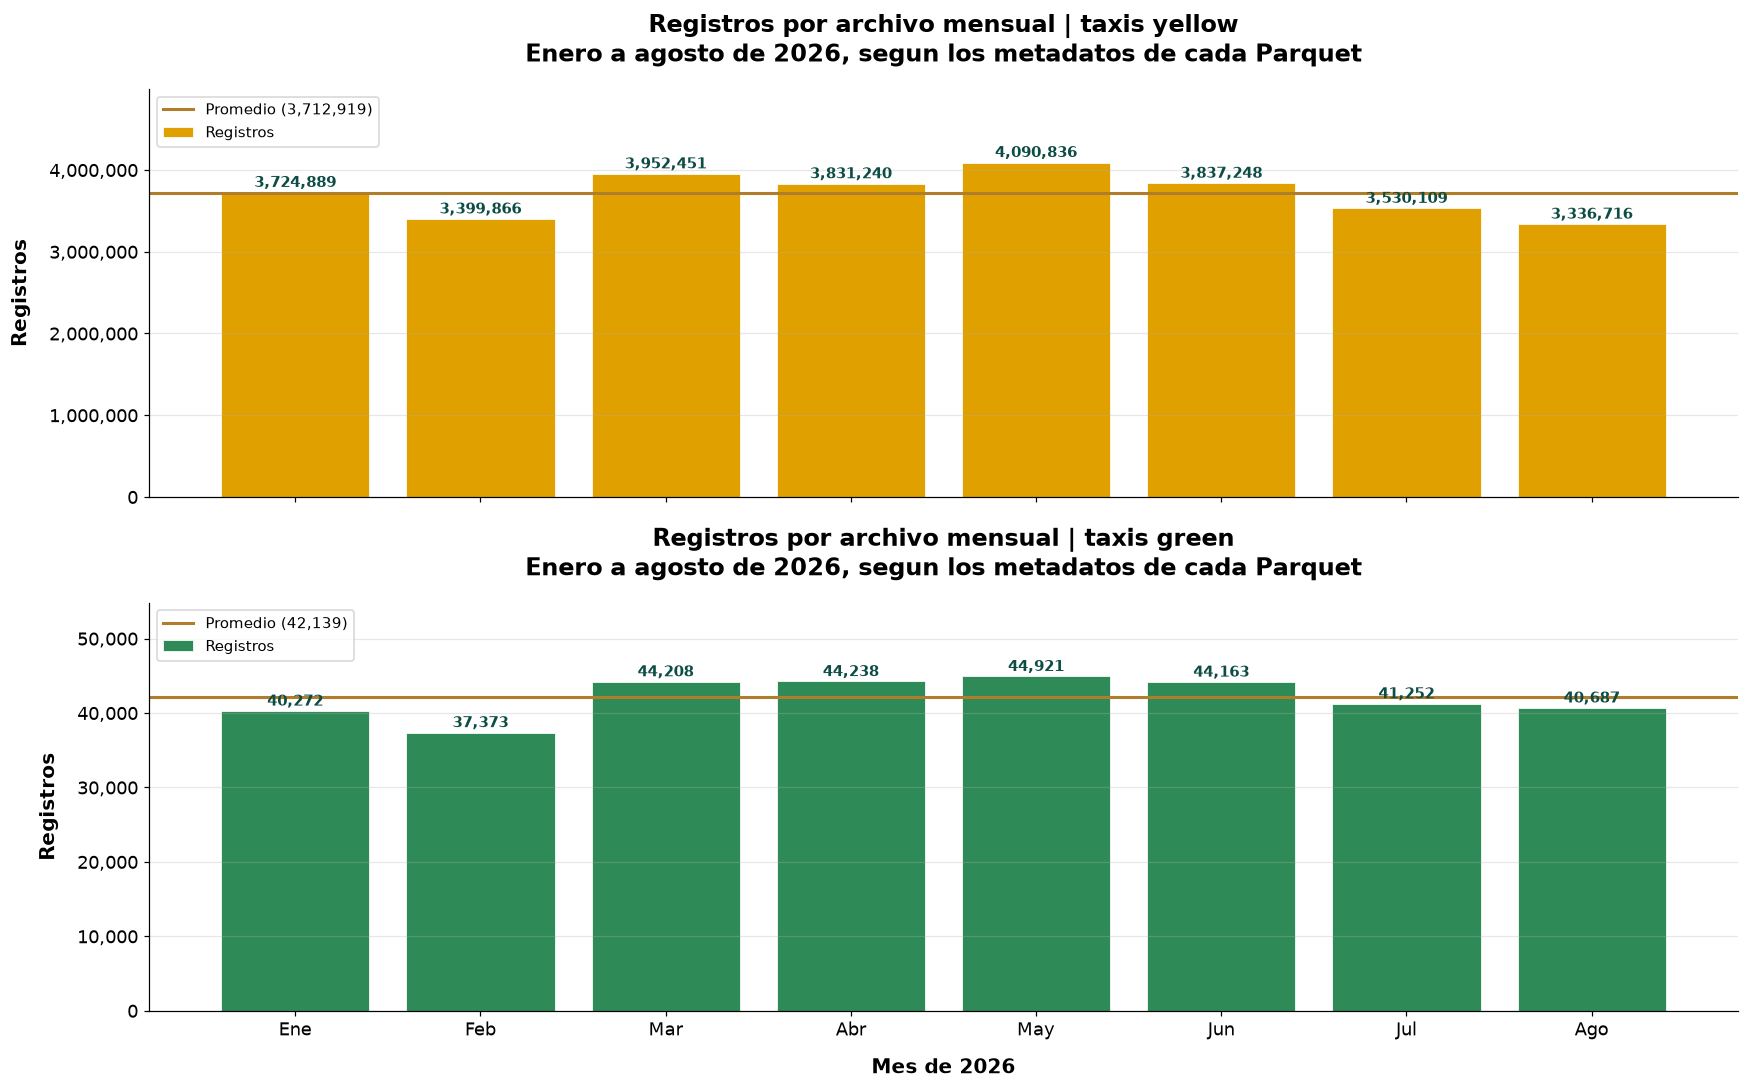

,tipo,anio,mes,archivo,filas,grupos_de_filas,bytes,escrito_por
0,yellow,2026,1,yellow_tripdata_2026-01.parquet,3724889,4,64165080,parquet-cpp-arrow version 16.1.0
1,yellow,2026,2,yellow_tripdata_2026-02.parquet,3399866,4,58683353,parquet-cpp-arrow version 16.1.0
2,yellow,2026,3,yellow_tripdata_2026-03.parquet,3952451,4,67891249,parquet-cpp-arrow version 16.1.0
3,yellow,2026,4,yellow_tripdata_2026-04.parquet,3831240,4,64818115,parquet-cpp-arrow version 24.0.0
4,yellow,2026,5,yellow_tripdata_2026-05.parquet,4090836,4,69699174,parquet-cpp-arrow version 16.1.0
5,yellow,2026,6,yellow_tripdata_2026-06.parquet,3837248,4,65465637,parquet-cpp-arrow version 21.0.0
6,yellow,2026,7,yellow_tripdata_2026-07.parquet,3530109,4,61685033,parquet-cpp-arrow version 21.0.0
7,yellow,2026,8,yellow_tripdata_2026-08.parquet,3336716,4,59043961,parquet-cpp-arrow version 21.0.0
8,green,2026,1,green_tripdata_2026-01.parquet,40272,1,991656,parquet-cpp-arrow version 16.1.0
9,green,2026,2,green_tripdata_2026-02.parquet,37373,1,920753,parquet-cpp-arrow version 16.1.0


In [11]:
con = consultas.conectar(vistas=False)
filas = filas_por_archivo(con)
fig, axes = graficar_filas_por_mes(filas)
plt.show()
filas

Los 16 archivos tienen un pie Parquet valido, que es lo primero que falla cuando un archivo quedo cortado. Suman 29,703,355 viajes amarillos y 337,114 verdes: los verdes son el 1.1% del total. Ningun mes se sale del patron. Los amarillos van de 3,336,716 (agosto) a 4,090,836 (mayo) alrededor de un promedio de 3,712,919, y los verdes de 37,373 (febrero) a 44,921 (mayo) alrededor de 42,139. Febrero queda bajo en los dos tipos porque tiene 28 dias, pero agosto es el mes mas flojo de amarillos aun contando por dia: unos 107,600 viajes diarios contra 121,400 en febrero y 132,000 en mayo, una caida de verano que se revisa en el exploratorio.

Un detalle que adelanta el ejercicio 3: no todos los archivos los escribio el mismo programa. Enero a mayo dicen `parquet-cpp-arrow 16.1.0` y junio a agosto `21.0.0`, pero abril de amarillos dice `24.0.0`, una version posterior a la de los meses siguientes, lo que sugiere que ese archivo se regenero despues de su primera publicacion. El cambio de version en junio coincide con una columna nueva, `request_source`, que aparece ese mes en los dos tipos.

## 8. Conclusiones

**Respuesta.** Si. Los dos servicios del ambiente responden (Jupyter 2.21.1, y Metabase v0.63.19 con su endpoint de salud en `ok`) y el sistema de descarga obtuvo los 16 archivos que la TLC tiene publicados para 2026: 8 de amarillos y 8 de verdes, de enero a agosto, con 100% de completitud byte por byte contra el servidor. Suman 30,040,469 viajes en 496 MiB. Una segunda corrida no descargo ni modifico ningun archivo.

**Como se determino que la descarga esta completa (2.7).** Con tres pruebas independientes, cada una pensada para un fallo distinto:

1. Que meses estan publicados se le pregunta al servidor en lugar de suponer doce, porque septiembre a diciembre todavia no existen.
2. Cada archivo publicado debe estar en disco con exactamente los bytes que anuncia el servidor, lo que descarta descargas cortadas.
3. Cada archivo debe tener un pie Parquet legible y un numero de registros en linea con los meses vecinos, lo que descartaria un archivo bien descargado pero vacio o roto en origen.

**Por que importa un ambiente reproducible (1.6).** El `Dockerfile` fija la version de Python y de cada paquete, y `docker compose` levanta los mismos dos servicios en cualquier computadora con un solo comando. En este laboratorio eso evita tres problemas concretos: que un resultado dependa de la version de DuckDB instalada en cada maquina (y que la base `.duckdb` deje de abrirse en Metabase si las versiones no coinciden), que alguien no pueda correr el analisis porque le falta una dependencia, y que los datos terminen en otra carpeta segun desde donde se corrio el script. Junto con los datos fuera de Git y un script que los vuelve a bajar, cualquier persona reconstruye exactamente el mismo punto de partida.

**Limitaciones.** El script omite un archivo solo porque existe, asi que si la TLC republica un mes corregido no lo vuelve a bajar por su cuenta. `--verificar` si lo detecta, porque el tamanio deja de coincidir, pero hay que correrlo. La comparacion por tamanio no veria una correccion que deje el archivo con exactamente los mismos bytes, algo muy poco probable.

**Siguiente paso.** El cuaderno 02 consulta estos archivos directamente con DuckDB para conocer su estructura y su calidad (ejercicio 3).